In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import LinearSVC

load_dotenv()

DATASET_DIR = os.getenv("DATASET_PATH")

if not DATASET_DIR:
    raise ValueError("DATASET_PATH not set in .env file")

print("DATASET_PATH:", DATASET_DIR)

TRAIN_JSON = os.path.join(DATASET_DIR, "train.json")
VAL_JSON   = os.path.join(DATASET_DIR, "val.json")
IMAGE_ROOT = os.path.join(DATASET_DIR, "image_features", "image_features")

MODALITIES = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]

DATASET_PATH: c:\Users\Charles Poon\Desktop\Yr4Sem2\STAT3612\kaggle-dataset


In [2]:
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_data = json.load(f)

print(f"Train cases: {len(train_data)}")
print(f"Val cases:   {len(val_data)}")

Train cases: 1983
Val cases:   283


# PCA reduced 2048 to 256 -> MLP (Multi-Layer Perceptron) F1: 0.56

Device: cuda
Loading features...
X_train: (1983, 8196)  X_val: (283, 8196)

Classes (5): [np.str_('Brain Metastase Tumour'), np.str_('Glioma'), np.str_('Meningioma'), np.str_('Pineal tumour and Choroid plexus tumour'), np.str_('Tumors of the sellar region')]

Class distribution (train):
  Brain Metastase Tumour: 252
  Glioma: 924
  Meningioma: 728
  Pineal tumour and Choroid plexus tumour: 23
  Tumors of the sellar region: 56

Fitting PCA (256 components)...
Explained variance: 0.922

Class weights (sqrt-inverse):
  Brain Metastase Tumour: 0.663
  Glioma: 0.346
  Meningioma: 0.390
  Pineal tumour and Choroid plexus tumour: 2.194
  Tumors of the sellar region: 1.406

Training...
Epoch  10 | train 1.2739 / 0.531 | val 1.2627 / 0.548  ✓
Epoch  20 | train 1.0405 / 0.634 | val 1.1380 / 0.572  ✓
Epoch  30 | train 0.7814 / 0.720 | val 1.0650 / 0.572  ✓
Epoch  40 | train 0.6107 / 0.775 | val 1.1363 / 0.587
Epoch  50 | train 0.5136 / 0.816 | val 1.1325 / 0.608

Early stop at epoch 55 — best epo

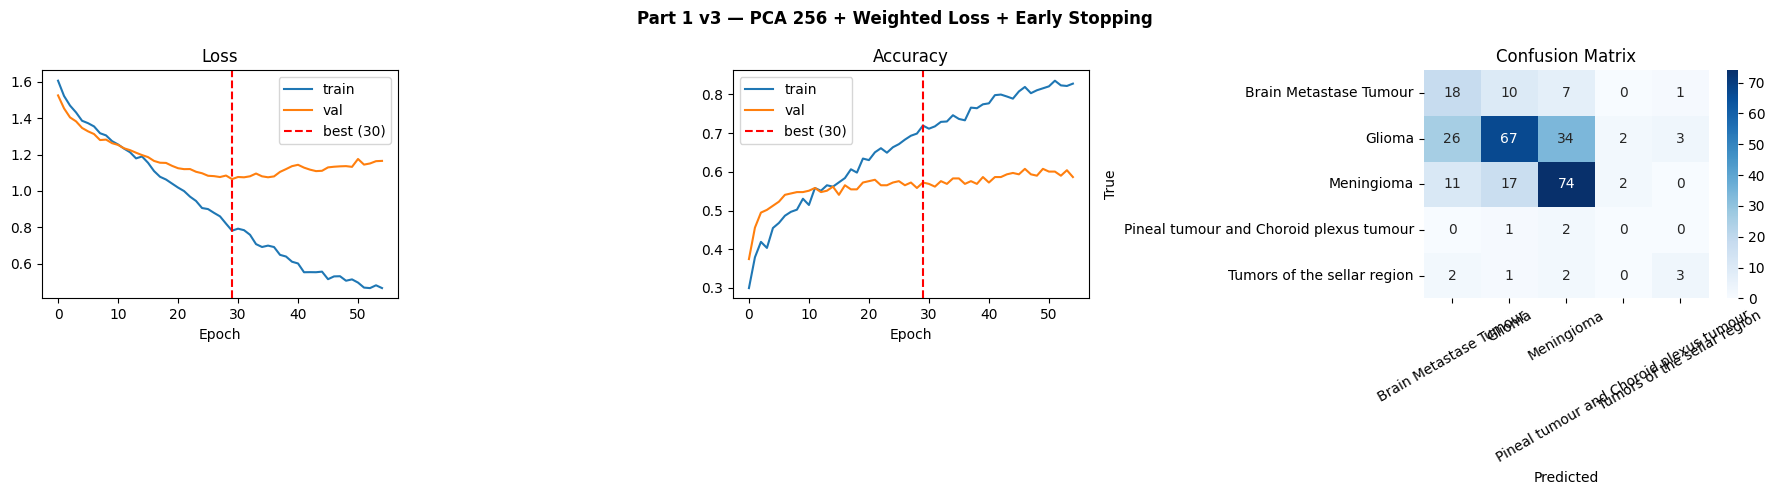

In [3]:
"""
Part 1 (v3) — PCA 256 + Weighted Loss + Early Stopping
Dropped SMOTE — too few real minority samples to synthesize reliably.
Kept: PCA 256, inverse-frequency class weights, early stopping on val loss.
"""

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODALITIES     = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]
FEATURE_DIM    = 2048
PCA_COMPONENTS = 256
EPOCHS         = 300
BATCH_SIZE     = 32
LR             = 3e-4      # slightly lower than before
DROPOUT        = 0.5
PATIENCE       = 25
print(f"Device: {DEVICE}")

# ── Feature loading ────────────────────────────────────────────────────────────
def load_all_modalities(case_id: str) -> np.ndarray:
    vecs, flags = [], []
    for mod in MODALITIES:
        npy_path = os.path.join(IMAGE_ROOT, str(case_id), mod, "image.npy")
        if os.path.exists(npy_path):
            vecs.append(np.load(npy_path).astype(np.float32))
            flags.append(1.0)
        else:
            vecs.append(np.zeros(FEATURE_DIM, dtype=np.float32))
            flags.append(0.0)
    return np.concatenate(vecs + [np.array(flags, dtype=np.float32)])

def build_xy_all(split_dict):
    X, y, ids = [], [], []
    for case_id, record in split_dict.items():
        X.append(load_all_modalities(case_id))
        ids.append(case_id)
        y.append(record["Overall_class"])
    return np.vstack(X), np.array(y), ids

print("Loading features...")
X_train_raw, y_train_str, train_ids = build_xy_all(train_data)
X_val_raw,   y_val_str,   val_ids   = build_xy_all(val_data)
print(f"X_train: {X_train_raw.shape}  X_val: {X_val_raw.shape}")

# ── Labels ─────────────────────────────────────────────────────────────────────
le = LabelEncoder().fit(y_train_str)
CLASSES, N_CLASSES = list(le.classes_), len(le.classes_)
y_train_enc = le.transform(y_train_str)
y_val_enc   = le.transform(y_val_str)

print(f"\nClasses ({N_CLASSES}): {CLASSES}")
print("\nClass distribution (train):")
counts = np.bincount(y_train_enc)
for i, (cls, cnt) in enumerate(zip(CLASSES, counts)):
    print(f"  {cls}: {cnt}")

# ── PCA ────────────────────────────────────────────────────────────────────────
print(f"\nFitting PCA ({PCA_COMPONENTS} components)...")
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_train = pca.fit_transform(X_train_raw).astype(np.float32)
X_val   = pca.transform(X_val_raw).astype(np.float32)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# ── Weighted loss ──────────────────────────────────────────────────────────────
# Use sqrt of inverse frequency — softer than raw inverse, less aggressive
class_weights = 1.0 / np.sqrt(counts.astype(np.float32))
class_weights = class_weights / class_weights.sum() * N_CLASSES   # normalize
class_weights = torch.tensor(class_weights).to(DEVICE)
print(f"\nClass weights (sqrt-inverse):")
for cls, w in zip(CLASSES, class_weights.cpu().numpy()):
    print(f"  {cls}: {w:.3f}")

# ── DataLoaders ────────────────────────────────────────────────────────────────
def make_loader(X, y, shuffle=True):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuffle
    )

train_loader = make_loader(X_train, y_train_enc)
val_loader   = make_loader(X_val,   y_val_enc, shuffle=False)

# ── MLP ────────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(PCA_COMPONENTS, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(256, 128),            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(128, 64),             nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(64, N_CLASSES)
        )
    def forward(self, x):
        return self.net(x)

# ── Train ──────────────────────────────────────────────────────────────────────
def train_model(model):
    model.to(DEVICE)
    opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                       factor=0.5, patience=10)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss, best_state, patience_ctr, best_epoch = float("inf"), None, 0, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tl, tc, tt = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb); loss = crit(out, yb)
            loss.backward(); opt.step()
            tl += loss.item()*len(yb)
            tc += (out.argmax(1)==yb).sum().item(); tt += len(yb)

        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vl += crit(out, yb).item()*len(yb)
                vc += (out.argmax(1)==yb).sum().item(); vt += len(yb)

        tl, vl = tl/tt, vl/vt
        ta, va = tc/tt, vc/vt
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        sch.step(vl)

        flag = ""
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0; best_epoch = epoch; flag = "  ✓"
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stop at epoch {epoch} — best epoch {best_epoch} "
                      f"(val loss {best_val_loss:.4f})")
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train {tl:.4f} / {ta:.3f} "
                  f"| val {vl:.4f} / {va:.3f}{flag}")

    model.load_state_dict(best_state)
    print(f"\nRestored best weights from epoch {best_epoch}")
    return history, best_epoch

print("\nTraining...")
model = MLP()
history, best_epoch = train_model(model)

# ── Evaluate ───────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        all_preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

print("\n" + "="*55)
print("  Part 1 (v3): PCA 256 + Weighted Loss + Early Stopping")
print("="*55)
print(classification_report(all_true, all_preds, target_names=CLASSES))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Part 1 v3 — PCA 256 + Weighted Loss + Early Stopping", fontweight="bold")

for ax, key, title in [(axes[0], "loss", "Loss"), (axes[1], "acc", "Accuracy")]:
    ax.plot(history[f"train_{key}"], label="train")
    ax.plot(history[f"val_{key}"],   label="val")
    ax.axvline(best_epoch-1, color="red", linestyle="--", label=f"best ({best_epoch})")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
#plt.savefig("part1_v3.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved → part1_v3.png")

# Transformer after PCA

Device: cuda
Loading radiomics...
Classes (5): [np.str_('Brain Metastase Tumour'), np.str_('Glioma'), np.str_('Meningioma'), np.str_('Pineal tumour and Choroid plexus tumour'), np.str_('Tumors of the sellar region')]
Train: 1983  Val: 283

Training Modality Transformer...
Parameters: 671,109


C:\Users\Charles Poon\AppData\Local\Temp\ipykernel_34368\2082780613.py:172: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=N_LAYERS)


Epoch  10 | train 1.3106/0.480 | val 1.2635/0.498
Epoch  20 | train 1.0798/0.554 | val 1.1547/0.580
Epoch  30 | train 0.8571/0.632 | val 1.2445/0.587

Early stop at epoch 39 — best epoch 19 (val loss 1.1303)

Restored best weights from epoch 19

  Modality Transformer — Classification Report
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour       0.44      0.11      0.18        36
                                 Glioma       0.60      0.71      0.65       132
                             Meningioma       0.60      0.63      0.62       104
Pineal tumour and Choroid plexus tumour       0.00      0.00      0.00         3
            Tumors of the sellar region       0.00      0.00      0.00         8

                               accuracy                           0.58       283
                              macro avg       0.33      0.29      0.29       283
                           weighted avg       0.56      0

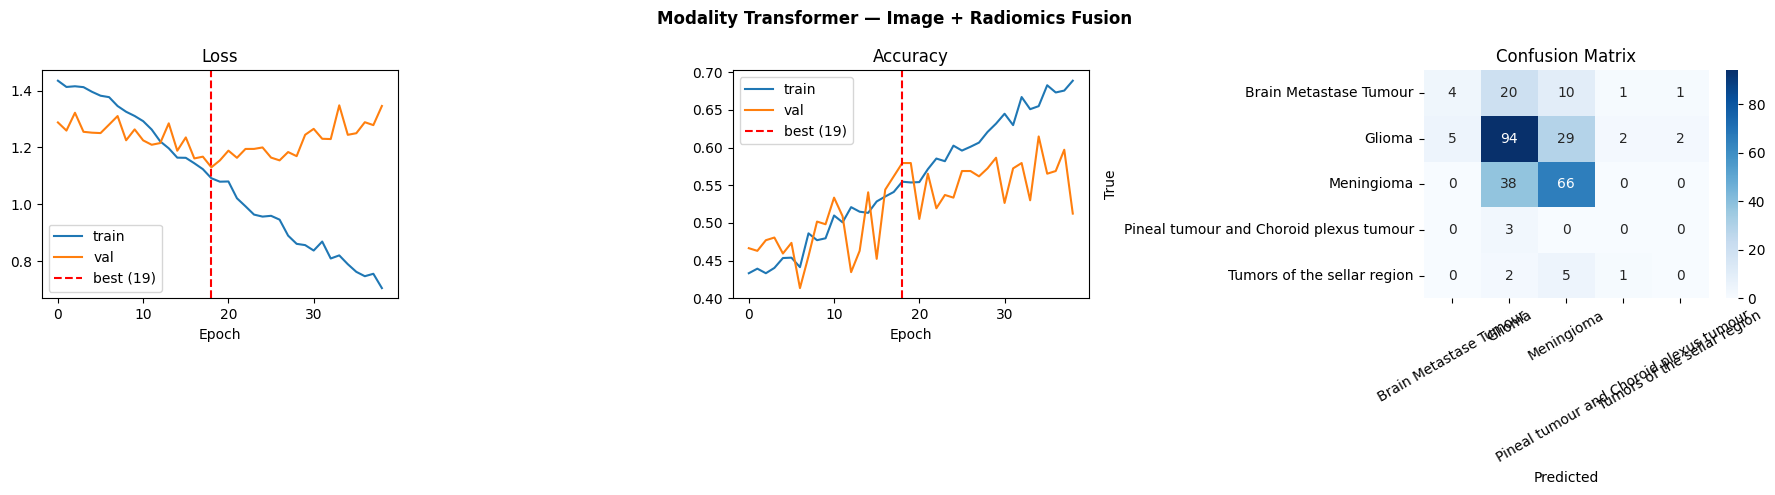

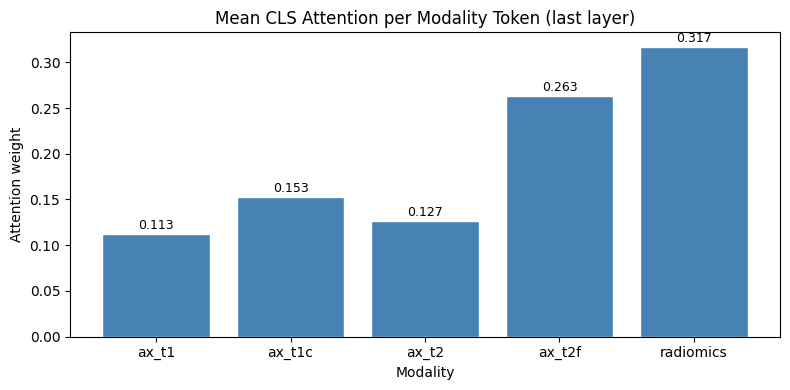

Saved → transformer_fusion.png  transformer_attention.png


In [4]:
"""
Transformer Fusion — Modality-as-Token
Each patient is represented as a sequence of tokens:
  [ax_t1, ax_t1c, ax_t2, ax_t2f, radiomics]  → 5 tokens
  - Image tokens:     2048-d feature vector (zero if missing)
  - Radiomics token:  20-d → projected to D_MODEL
  - Presence mask:    missing tokens are masked out of attention

Architecture:
  Per-modality linear projection → D_MODEL
  + learnable modality type embeddings
  → Transformer Encoder (multi-head self-attention)
  → CLS token output → classifier head
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODALITIES  = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]
IMG_DIM     = 2048
RAD_DIM     = 20
D_MODEL     = 128    # projection dimension for all tokens
N_HEADS     = 4      # attention heads (D_MODEL must be divisible)
N_LAYERS    = 2      # transformer encoder layers
DROPOUT     = 0.3
EPOCHS      = 100
BATCH_SIZE  = 32
LR          = 3e-4
PATIENCE    = 20
print(f"Device: {DEVICE}")

# ── Radiomics loading ──────────────────────────────────────────────────────────
RAD_FEATURES = [
    "rad_firstorder_Mean", "rad_firstorder_Entropy",
    "rad_firstorder_90Percentile", "rad_glcm_Contrast", "rad_glcm_JointEntropy"
]
RAD_DIR = os.path.join(DATASET_DIR, "radiomics_info")

def load_radiomics_split(split: str) -> pd.DataFrame:
    dfs = []
    for mod in MODALITIES:
        path = os.path.join(RAD_DIR, split, f"{mod}_radiomics_{split}.csv")
        df = pd.read_csv(path)[["case_id"] + RAD_FEATURES].rename(
            columns={f: f"{mod}_{f}" for f in RAD_FEATURES}
        )
        dfs.append(df)
    merged = dfs[0]
    for df in dfs[1:]:
        merged = merged.merge(df, on="case_id", how="inner")
    return merged.dropna().set_index("case_id")

print("Loading radiomics...")
rad_train_df = load_radiomics_split("train")
rad_val_df   = load_radiomics_split("val")

rad_scaler = StandardScaler().fit(rad_train_df.values)
rad_train_sc = rad_scaler.transform(rad_train_df.values).astype(np.float32)
rad_val_sc   = rad_scaler.transform(rad_val_df.values).astype(np.float32)

rad_train_lookup = {str(cid): rad_train_sc[i] for i, cid in enumerate(rad_train_df.index)}
rad_val_lookup   = {str(cid): rad_val_sc[i]   for i, cid in enumerate(rad_val_df.index)}

# ── Labels ─────────────────────────────────────────────────────────────────────
all_labels = [r["Overall_class"] for r in train_data.values()]
le = LabelEncoder().fit(all_labels)
CLASSES, N_CLASSES = list(le.classes_), len(le.classes_)
print(f"Classes ({N_CLASSES}): {CLASSES}")

# ── Dataset ────────────────────────────────────────────────────────────────────
N_TOKENS = len(MODALITIES) + 1   # 4 image + 1 radiomics

class ModalityDataset(Dataset):
    """
    Returns per patient:
      tokens  : (N_TOKENS, max_dim)  — zero-padded raw feature vectors
      mask    : (N_TOKENS,)          — True = token is MISSING (pad mask)
      label   : int
    """
    def __init__(self, split_dict: dict, rad_lookup: dict):
        self.samples = []
        for case_id, record in split_dict.items():
            label = le.transform([record["Overall_class"]])[0]

            img_vecs, img_mask = [], []
            for mod in MODALITIES:
                npy_path = os.path.join(IMAGE_ROOT, str(case_id), mod, "image.npy")
                if os.path.exists(npy_path):
                    img_vecs.append(np.load(npy_path).astype(np.float32))
                    img_mask.append(False)   # present
                else:
                    img_vecs.append(np.zeros(IMG_DIM, dtype=np.float32))
                    img_mask.append(True)    # missing → mask out

            # radiomics token
            if case_id in rad_lookup:
                rad_vec  = rad_lookup[case_id]
                rad_miss = False
            else:
                rad_vec  = np.zeros(RAD_DIM, dtype=np.float32)
                rad_miss = True

            self.samples.append((img_vecs, img_mask, rad_vec, rad_miss, label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_vecs, img_mask, rad_vec, rad_miss, label = self.samples[idx]
        return (
            [torch.tensor(v) for v in img_vecs],
            torch.tensor(img_mask, dtype=torch.bool),
            torch.tensor(rad_vec),
            torch.tensor(rad_miss, dtype=torch.bool),
            torch.tensor(label, dtype=torch.long)
        )


def collate_fn(batch):
    img_vecs_list, img_masks, rad_vecs, rad_misses, labels = zip(*batch)
    # img_vecs_list: list of (list of 4 tensors)
    img_tokens = torch.stack([
        torch.stack(vecs) for vecs in img_vecs_list
    ])   # (B, 4, IMG_DIM)
    img_mask   = torch.stack(img_masks)                    # (B, 4)
    rad_tokens = torch.stack(rad_vecs)                     # (B, RAD_DIM)
    rad_mask   = torch.stack(rad_misses).unsqueeze(1)      # (B, 1)
    pad_mask   = torch.cat([img_mask, rad_mask], dim=1)    # (B, 5)
    labels     = torch.stack(labels)
    return img_tokens, pad_mask, rad_tokens, labels


train_ds = ModalityDataset(train_data, rad_train_lookup)
val_ds   = ModalityDataset(val_data,   rad_val_lookup)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

# ── Model ──────────────────────────────────────────────────────────────────────
class ModalityTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        # Project each modality into D_MODEL
        self.img_proj = nn.Linear(IMG_DIM, D_MODEL)
        self.rad_proj = nn.Linear(RAD_DIM, D_MODEL)

        # Learnable modality-type embeddings (one per token position)
        self.type_embed = nn.Embedding(N_TOKENS, D_MODEL)

        # CLS token (prepended to the sequence)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, D_MODEL))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=N_HEADS,
            dim_feedforward=D_MODEL * 4,
            dropout=DROPOUT,
            batch_first=True,
            norm_first=True      # pre-norm for stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=N_LAYERS)

        # Classifier head on CLS token
        self.head = nn.Sequential(
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, N_CLASSES)
        )

    def forward(self, img_tokens, pad_mask, rad_tokens):
        """
        img_tokens : (B, 4, IMG_DIM)
        pad_mask   : (B, 5)  True = missing
        rad_tokens : (B, RAD_DIM)
        """
        B = img_tokens.size(0)

        # Project image tokens
        img_proj = self.img_proj(img_tokens)                # (B, 4, D_MODEL)

        # Project radiomics token
        rad_proj = self.rad_proj(rad_tokens).unsqueeze(1)   # (B, 1, D_MODEL)

        # Concatenate → (B, 5, D_MODEL)
        tokens = torch.cat([img_proj, rad_proj], dim=1)

        # Add modality type embeddings
        type_ids = torch.arange(N_TOKENS, device=tokens.device)
        tokens = tokens + self.type_embed(type_ids)         # broadcast over B

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D_MODEL)
        tokens = torch.cat([cls, tokens], dim=1)            # (B, 6, D_MODEL)

        # Extend pad mask for CLS (never masked)
        cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=pad_mask.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)  # (B, 6)

        # Transformer
        out = self.transformer(tokens, src_key_padding_mask=full_mask)  # (B, 6, D)

        # Classify from CLS token
        return self.head(out[:, 0, :])


# ── Weighted loss ──────────────────────────────────────────────────────────────
y_train_all = np.array([le.transform([r["Overall_class"]])[0] for r in train_data.values()])
counts = np.bincount(y_train_all)
class_weights = 1.0 / np.sqrt(counts.astype(np.float32))
class_weights = class_weights / class_weights.sum() * N_CLASSES
class_weights = torch.tensor(class_weights).to(DEVICE)

# ── Training ───────────────────────────────────────────────────────────────────
def train_model(model):
    model.to(DEVICE)
    opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss, best_state, patience_ctr, best_epoch = float("inf"), None, 0, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tl, tc, tt = 0, 0, 0
        for img_tok, pad_mask, rad_tok, yb in train_loader:
            img_tok  = img_tok.to(DEVICE)
            pad_mask = pad_mask.to(DEVICE)
            rad_tok  = rad_tok.to(DEVICE)
            yb       = yb.to(DEVICE)
            opt.zero_grad()
            out  = model(img_tok, pad_mask, rad_tok)
            loss = crit(out, yb)
            loss.backward(); opt.step()
            tl += loss.item()*len(yb)
            tc += (out.argmax(1)==yb).sum().item(); tt += len(yb)
        sch.step()

        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for img_tok, pad_mask, rad_tok, yb in val_loader:
                img_tok  = img_tok.to(DEVICE)
                pad_mask = pad_mask.to(DEVICE)
                rad_tok  = rad_tok.to(DEVICE)
                yb       = yb.to(DEVICE)
                out = model(img_tok, pad_mask, rad_tok)
                vl += crit(out, yb).item()*len(yb)
                vc += (out.argmax(1)==yb).sum().item(); vt += len(yb)

        tl, vl = tl/tt, vl/vt
        ta, va = tc/tt, vc/vt
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)

        flag = ""
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0; best_epoch = epoch; flag = "  ✓"
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stop at epoch {epoch} — best epoch {best_epoch} "
                      f"(val loss {best_val_loss:.4f})")
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train {tl:.4f}/{ta:.3f} "
                  f"| val {vl:.4f}/{va:.3f}{flag}")

    model.load_state_dict(best_state)
    print(f"\nRestored best weights from epoch {best_epoch}")
    return history, best_epoch


print("\nTraining Modality Transformer...")
model = ModalityTransformer()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")
history, best_epoch = train_model(model)

# ── Evaluate ───────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for img_tok, pad_mask, rad_tok, yb in val_loader:
        out = model(img_tok.to(DEVICE), pad_mask.to(DEVICE), rad_tok.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

print("\n" + "="*55)
print("  Modality Transformer — Classification Report")
print("="*55)
print(classification_report(all_true, all_preds, target_names=CLASSES))

# ── Attention visualization (last layer, first head, CLS row) ─────────────────
TOKEN_NAMES = MODALITIES + ["radiomics"]

def get_attention_weights(model, img_tok, pad_mask, rad_tok):
    """Extract CLS→token attention from the last transformer layer."""
    hooks, attn_weights = [], []

    def hook_fn(module, input, output):
        # output[1] is the attention weight matrix when need_weights=True
        # TransformerEncoderLayer stores self_attn
        pass

    # Forward with hooks — re-implement a forward pass capturing attn
    model.eval()
    with torch.no_grad():
        B = img_tok.size(0)
        img_proj = model.img_proj(img_tok)
        rad_proj = model.rad_proj(rad_tok).unsqueeze(1)
        tokens   = torch.cat([img_proj, rad_proj], dim=1)
        type_ids = torch.arange(N_TOKENS, device=tokens.device)
        tokens   = tokens + model.type_embed(type_ids)
        cls      = model.cls_token.expand(B, -1, -1)
        tokens   = torch.cat([cls, tokens], dim=1)
        cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=pad_mask.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)

        # Run through each layer manually to capture attn
        x = tokens
        for layer in model.transformer.layers:
            # Pre-norm
            x_norm = layer.norm1(x)
            attn_out, attn_w = layer.self_attn(
                x_norm, x_norm, x_norm,
                key_padding_mask=full_mask,
                need_weights=True,
                average_attn_weights=True
            )
            x = x + layer.dropout1(attn_out)
            x = x + layer.dropout2(layer.linear2(
                layer.dropout(layer.activation(layer.linear1(layer.norm2(x))))
            ))
        # attn_w: (B, seq_len, seq_len) — last layer
        # CLS token is index 0, modality tokens are 1..6
        cls_attn = attn_w[:, 0, 1:]   # (B, N_TOKENS)
    return cls_attn.cpu().numpy()


# Plot mean attention per modality token across val set
print("\nComputing attention weights...")
all_attn = []
with torch.no_grad():
    for img_tok, pad_mask, rad_tok, _ in val_loader:
        attn = get_attention_weights(
            model,
            img_tok.to(DEVICE),
            pad_mask.to(DEVICE),
            rad_tok.to(DEVICE)
        )
        all_attn.append(attn)

all_attn = np.vstack(all_attn)   # (N_val, N_TOKENS)
mean_attn = all_attn.mean(axis=0)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Modality Transformer — Image + Radiomics Fusion", fontweight="bold")

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].axvline(best_epoch-1, color="red", linestyle="--", label=f"best ({best_epoch})")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].axvline(best_epoch-1, color="red", linestyle="--", label=f"best ({best_epoch})")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("transformer_fusion.png", dpi=150, bbox_inches="tight")
plt.show()

# Attention bar chart
fig2, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(TOKEN_NAMES, mean_attn, color="steelblue", edgecolor="white")
ax.set_title("Mean CLS Attention per Modality Token (last layer)")
ax.set_ylabel("Attention weight"); ax.set_xlabel("Modality")
for bar, val in zip(bars, mean_attn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("transformer_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → transformer_fusion.png  transformer_attention.png")

# Soft Voting using 4 graphs + radiomics + clinical

In [6]:
"""
Part 2 — Per-modality MLPs + Ensemble (Soft Voting & Naive Bayes)
FIXED: Added Radiomics MLP + safe ensemble (no KeyError)
"""

import pandas as pd
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODALITIES  = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]
FEATURE_DIM = 2048
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 1e-3
DROPOUT     = 0.4
print(f"Device: {DEVICE}")

# ── Label encoder ──────────────────────────────────────────────────────────────
all_labels = [r["Overall_class"] for r in train_data.values()]
le = LabelEncoder().fit(all_labels)
CLASSES   = list(le.classes_)
N_CLASSES = len(CLASSES)
print(f"Classes ({N_CLASSES}): {CLASSES}")

# ── Tabular probs ──────────────────────────────────────────────────────────────
tabular_prob_df = pd.read_csv("tabular_features_predict_proba.csv")
tabular_prob_df.set_index("Id", inplace=True)
tabular_cols = [f"prob_{c}" for c in CLASSES]

# ══════════════════════════════════════════════════════════════════════════════
# A) RADIOMICS LOADING (FROM YOUR V2)
# ══════════════════════════════════════════════════════════════════════════════
RAD_FEATURES = [
    "rad_firstorder_Mean", "rad_firstorder_Entropy",
    "rad_firstorder_90Percentile", "rad_glcm_Contrast", "rad_glcm_JointEntropy"
]
RAD_DIR = os.path.join(DATASET_DIR, "radiomics_info")

def load_radiomics_split(split: str):
    dfs = []
    for mod in MODALITIES:
        path = os.path.join(RAD_DIR, split, f"{mod}_radiomics_{split}.csv")
        df = pd.read_csv(path)
        df = df[["case_id"] + RAD_FEATURES].rename(
            columns={f: f"{mod}_{f}" for f in RAD_FEATURES}
        )
        dfs.append(df)

    merged = dfs[0]
    for df in dfs[1:]:
        merged = merged.merge(df, on="case_id", how="inner")

    return merged.dropna().set_index("case_id")

print("\nLoading radiomics...")
rad_train_df = load_radiomics_split("train")
rad_val_df   = load_radiomics_split("val")

def rad_xy(rad_df, split_dict):
    X, y, ids = [], [], []
    for cid in rad_df.index:
        key = str(cid)
        if key not in split_dict:
            continue
        X.append(rad_df.loc[cid].values.astype(np.float32))
        y.append(split_dict[key]["Overall_class"])
        ids.append(key)
    return np.vstack(X), np.array(y), ids

X_rad_train, y_rad_train, rad_train_ids = rad_xy(rad_train_df, train_data)
X_rad_val,   y_rad_val,   rad_val_ids   = rad_xy(rad_val_df, val_data)

# scale
scaler = StandardScaler().fit(X_rad_train)
X_rad_train = scaler.transform(X_rad_train).astype(np.float32)
X_rad_val   = scaler.transform(X_rad_val).astype(np.float32)

# lookup
rad_val_lookup = {str(cid): X_rad_val[i] for i, cid in enumerate(rad_val_ids)}

# ══════════════════════════════════════════════════════════════════════════════
# B) IMAGE LOADING
# ══════════════════════════════════════════════════════════════════════════════
def load_modality_xy(split_dict: dict, modality: str):
    X, y, ids = [], [], []
    for case_id, record in split_dict.items():
        npy_path = os.path.join(IMAGE_ROOT, str(case_id), modality, "image.npy")
        if not os.path.exists(npy_path):
            continue
        X.append(np.load(npy_path).astype(np.float32))
        y.append(record["Overall_class"])
        ids.append(case_id)
    return np.vstack(X), np.array(y), ids

# ══════════════════════════════════════════════════════════════════════════════
# C) MODELS
# ══════════════════════════════════════════════════════════════════════════════
class ImageMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FEATURE_DIM, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(128, N_CLASSES)
        )
    def forward(self, x): return self.net(x)

class RadiomicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(32, N_CLASSES)
        )
    def forward(self, x): return self.net(x)

def train_mlp(model, X_tr, y_tr, X_vl, y_vl, name):
    y_tr = le.transform(y_tr)
    y_vl = le.transform(y_vl)

    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)), batch_size=BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(TensorDataset(torch.tensor(X_vl), torch.tensor(y_vl)), batch_size=BATCH_SIZE)

    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

    return model

# ══════════════════════════════════════════════════════════════════════════════
# D) TRAIN MODELS
# ══════════════════════════════════════════════════════════════════════════════
models = {}

# image
for mod in MODALITIES:
    print(f"\nTraining {mod}")
    X_tr, y_tr, _ = load_modality_xy(train_data, mod)
    X_vl, y_vl, _ = load_modality_xy(val_data, mod)
    models[mod] = train_mlp(ImageMLP(), X_tr, y_tr, X_vl, y_vl, mod)

# radiomics (FIX)
print("\nTraining radiomics")
models["radiomics"] = train_mlp(
    RadiomicsMLP(),
    X_rad_train, y_rad_train,
    X_rad_val,   y_rad_val,
    "radiomics"
)

# ══════════════════════════════════════════════════════════════════════════════
# E) ENSEMBLE
# ══════════════════════════════════════════════════════════════════════════════
def get_probs(model, x):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(x[None], dtype=torch.float32).to(DEVICE)
        return F.softmax(model(x), dim=1).cpu().numpy()[0]

def ensemble_predict(split_dict):
    pred_vote, pred_nb, true_labels = [], [], []

    for case_id, record in split_dict.items():
        prob_list = []

        # image
        for mod in MODALITIES:
            path = os.path.join(IMAGE_ROOT, str(case_id), mod, "image.npy")
            if os.path.exists(path):
                vec = np.load(path).astype(np.float32)
                prob_list.append(get_probs(models[mod], vec))

        # radiomics (SAFE FIX)
        if "radiomics" in models and case_id in rad_val_lookup:
            prob_list.append(get_probs(models["radiomics"], rad_val_lookup[case_id]))

        # tabular
        case_id_int = int(case_id)
        if case_id_int in tabular_prob_df.index:
            prob_list.append(
                tabular_prob_df.loc[case_id_int, tabular_cols].values.astype(np.float32)
            )

        if not prob_list:
            continue

        probs = np.stack(prob_list)
        probs = np.clip(probs, 1e-9, 1.0)  # stability

        pred_vote.append(probs.mean(axis=0).argmax())
        pred_nb.append(np.log(probs).sum(axis=0).argmax())
        true_labels.append(le.transform([record["Overall_class"]])[0])

    return np.array(true_labels), np.array(pred_vote), np.array(pred_nb)

# ══════════════════════════════════════════════════════════════════════════════
# F) RUN
# ══════════════════════════════════════════════════════════════════════════════
print("\nRunning ensemble...")
true, pred_vote, pred_nb = ensemble_predict(val_data)

for preds, name in [(pred_vote, "Soft Voting"), (pred_nb, "Naive Bayes")]:
    print(f"\n{name}")
    print(classification_report(true, preds, target_names=CLASSES))

Device: cuda
Classes (5): [np.str_('Brain Metastase Tumour'), np.str_('Glioma'), np.str_('Meningioma'), np.str_('Pineal tumour and Choroid plexus tumour'), np.str_('Tumors of the sellar region')]

Loading radiomics...

Training ax_t1

Training ax_t1c

Training ax_t2

Training ax_t2f

Training radiomics

Running ensemble...

Soft Voting
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour       0.40      0.28      0.33        36
                                 Glioma       0.64      0.67      0.65       132
                             Meningioma       0.63      0.72      0.67       104
Pineal tumour and Choroid plexus tumour       0.00      0.00      0.00         3
            Tumors of the sellar region       0.50      0.12      0.20         8

                               accuracy                           0.61       283
                              macro avg       0.43      0.36      0.37       283
            

c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Charles Poon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  